
=== K-Means Results ===
Number of Clusters: 4
Silhouette Score: 0.0232

=== Hierarchical Results ===
Number of Clusters: 4


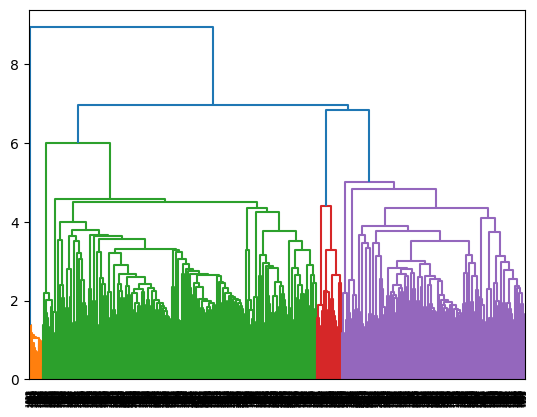

In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

cats = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

data = fetch_20newsgroups(subset='train', categories=cats)
X = TfidfVectorizer(stop_words='english', max_features=1000).fit_transform(data.data)

k = len(cats)

# K-Means
kmeans = KMeans(n_clusters=k).fit(X)
labels = kmeans.labels_

print("\n=== K-Means Results ===")
print("Number of Clusters:", k)
print("Silhouette Score:", round(silhouette_score(X, labels), 4))

# Hierarchical
hier = AgglomerativeClustering(n_clusters=k).fit(X.toarray())

print("\n=== Hierarchical Results ===")
print("Number of Clusters:", k)

# Dendrogram
Z = linkage(X.toarray(), method='ward')
dendrogram(Z)
plt.show()
